## Welcome to the basic neural network tutorial!
The following notebook is designed to walk through the process of building and training your first scikit based algorithm using the standalone MaCh3 python utilities!

If you're writing scripts this is encapsulate in the objects in `MaCh3PythonUtils/config_reader` however this guide aims to break apart the process of writing the code for yourself!

The first step is to load in a MaCh3 MCMC fit as input file. This is done using the ChainHandler class!

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory

# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import gdown

Using mps device

In [2]:
# Download file from google drive

file_url="https://drive.google.com/file/d/1iE6xFhn3BH_HnLUfQ7KFGy2wfeH52Rwf/view?usp=sharing"

# download the file
input_file = Path("../models/demo_chain.root")

if not input_file.exists():
    # download the file
    input_file.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(file_url, str(input_file), quiet=False, fuzzy=True)


In [3]:
# Set up file properties
chain_name = 'posteriors'
verbose=False

chain_handler = ChainHandler(str(input_file), chain_name, verbose=verbose)

Attempting to open ../models/demo_chain.root
Succesfully opened ../models/demo_chain.root:posteriors


Okay, now we've loaded in a file we need to do a bit of processing. This means we need to select the variables we care about and apply parameter cuts

In [4]:
# Firstly we set things we want to ignore, these are parameters we really don't care about/want to learn!
chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "Log", "LogL_systematic_osc_cov"])

# Now we add parameters we care about. Note this only need to be a substring of the full name
chain_handler.add_additional_plots(["sin2th", "delm2", "delta", "xsec"])

# The fitting label is special, it's the thing we want to train our network to predict
fitting_label = "LogL"
# We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
chain_handler.add_additional_plots(fitting_label, True)

# Finally we can do some cuts to get rid of things like burn-in
chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<1234", "step>10000"])

# Last step is convert the chain into a pandas dataframe
chain_handler.convert_ttree_to_array()

print(chain_handler)

Let's quickly use the chain handler to make a plot of the trace and posterior!

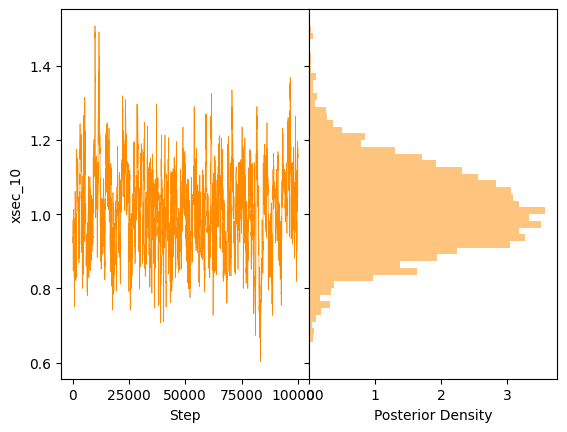

In [12]:
# We're just grab the first column of our pandas dataframe
parameter_vals = chain_handler.ttree_array.iloc[:,10]
# Grab the name from column label
param_label = chain_handler.ttree_array.columns[10]

# Setup figure
fig, (trace_ax, post_ax) = plt.subplots(nrows=1, ncols=2)

# Plot traces
trace_ax.plot(parameter_vals, linewidth=0.5, color='darkorange')

# Plot posterior
post_ax.hist(parameter_vals, bins=50, color='darkorange', alpha=0.5, orientation='horizontal', density=True)

# Merge the two axes
plt.setp(post_ax.get_yticklabels(), visible=False)
fig.subplots_adjust(wspace=.0)

# Set the axis labels
trace_ax.set_xlabel("Step")
post_ax.set_xlabel("Posterior Density")
trace_ax.set_ylabel(param_label)

plt.show()

## Machine learning
Okay now we've done some very basic file manipulation, it's time for some machine learning!
All algorithms use the same common `MLFactory` interface so let's go about configuring it!

In [15]:
print(chain_handler.ttree_array)

         xsec_0    xsec_1    xsec_2    xsec_3    xsec_4    xsec_5    xsec_6  \
0      1.193532  1.011216  1.250193  1.067571  0.793567  1.070356  0.951044   
1      1.193532  1.011216  1.250193  1.067571  0.793567  1.070356  0.951044   
2      1.193532  1.011216  1.250193  1.067571  0.793567  1.070356  0.951044   
3      1.193532  1.011216  1.250193  1.067571  0.793567  1.070356  0.951044   
4      1.193532  1.011216  1.250193  1.067571  0.793567  1.070356  0.951044   
...         ...       ...       ...       ...       ...       ...       ...   
99994  1.159800  1.084834  1.117669  0.915306  1.017123  0.966494  1.053807   
99995  1.159800  1.084834  1.117669  0.915306  1.017123  0.966494  1.053807   
99996  1.159800  1.084834  1.117669  0.915306  1.017123  0.966494  1.053807   
99997  1.159800  1.084834  1.117669  0.915306  1.017123  0.966494  1.053807   
99998  1.159800  1.084834  1.117669  0.915306  1.017123  0.966494  1.053807   

         xsec_7    xsec_8    xsec_9  ...  xsec_20  

In [6]:
# First step we need to initialise the factory
from pathlib import Path


model_output=Path("../models/my_model")
# Make sure the model output directory exists
model_output.parent.mkdir(parents=True, exist_ok=True)

# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory = MLFactory(chain_handler, fitting_label, f"{model_output}.pdf")

Now we need to define a model, for this demonstration we'll make a very simple BDT!

In [7]:
# Now we can make the model
ml_model = ml_factory.make_interface('SciKit', 'histboost', loss='absolute_error', max_iter=10000, verbose=1, max_leaf_nodes=250)

# Let's use 20% of the data for testing
ml_model.set_training_test_set(0.8)

In [8]:
# Now we need to train our network
ml_model.train_model()

Training Model
Binning 0.004 GB of training data: 0.044 s
Binning 0.000 GB of validation data: 0.002 s
Fitting gradient boosted rounds:
Fit 2018 trees in 114.653 s, (504500 total leaves)
Time spent computing histograms: 39.502s
Time spent finding best splits:  26.448s
Time spent applying splits:      30.440s
Time spent predicting:           0.235s


Training Results!

Mean Absolute Error : 0.04148528398055918

Line of best fit : y=1.0365280996185011x + 0.015868967834841867

Saving QQ to train_qq_plot.pdf

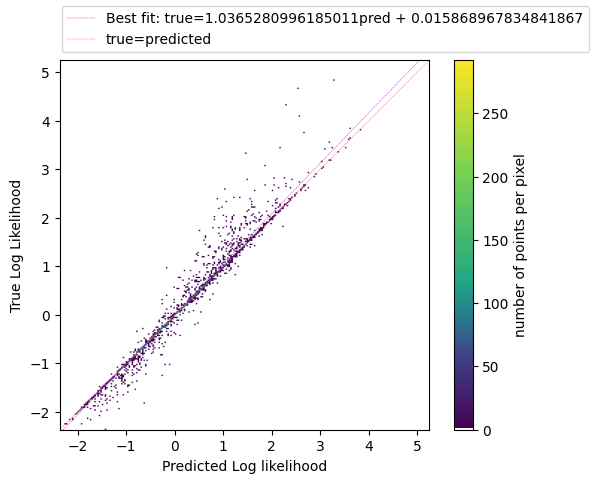

mean: 0.015309732404439813, std dev: 0.16210745016374023

=====

Testing Results!

Mean Absolute Error : 0.07731394885892323

Line of best fit : y=1.053130362268995x + 0.0269018681571601

Saving QQ to .pdf

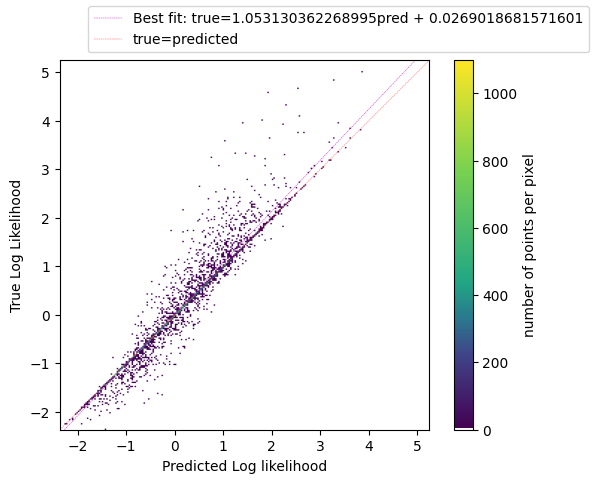

mean: 0.02570469860532164, std dev: 0.23229264633034993

=====

In [9]:
# Now we need to test
ml_model.test_model()


In [10]:
# Now we can save it
ml_model.save_model(f"{model_output}.keras")


# We need to save the scaling information
ml_model.save_scaler(str(model_output.parent.joinpath(Path("my_scaler.pkl"))))
print("Model saved to: ", model_output)
print("Scaler saved to: ", model_output.parent.joinpath(Path("my_scaler.pkl")))


Saving to ../models/my_model.keras

Model saved to:  ../models/my_model
Scaler saved to:  ../models/my_scaler.pkl
